<a href="https://colab.research.google.com/github/manisha02710/FDS-EXPERIMENT/blob/main/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving sales_data.csv to sales_data.csv
Original Data:
   day product  sales  quantity
0  Mon   Apple  120.0      12.0
1  Mon  Banana   80.0       8.0
2  Tue   Apple  150.0      15.0
3  Tue  Orange   90.0       9.0
4  Wed  Banana    NaN      10.0
5  Wed   Mango  200.0       NaN
6  Thu   Apple  180.0      18.0
7  Thu   Mango  220.0      20.0
8  Fri  Orange  110.0      11.0
9  Fri  Banana   95.0      10.0

After Handling Missing Values:
   day product       sales   quantity
0  Mon   Apple  120.000000  12.000000
1  Mon  Banana   80.000000   8.000000
2  Tue   Apple  150.000000  15.000000
3  Tue  Orange   90.000000   9.000000
4  Wed  Banana  138.333333  10.000000
5  Wed   Mango  200.000000  12.555556
6  Thu   Apple  180.000000  18.000000
7  Thu   Mango  220.000000  20.000000
8  Fri  Orange  110.000000  11.000000
9  Fri  Banana   95.000000  10.000000

After Removing Remaining Missing Values:
   day product       sales   quantity
0  Mon   Apple  120.000000  12.000000
1  Mon  Banana   80.00000

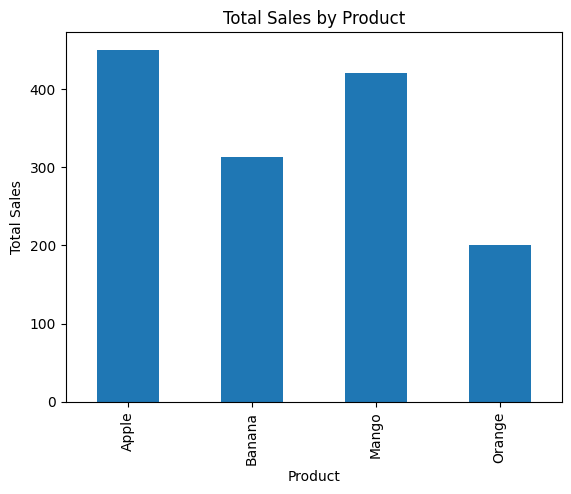

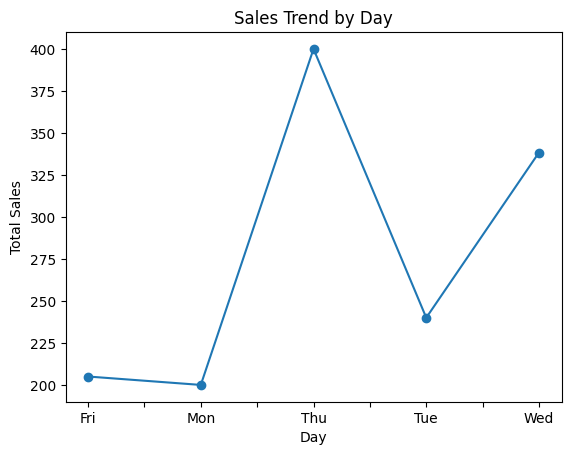


Pivot Table:
product  Apple      Banana  Mango  Orange
day                                      
Fri        NaN   95.000000    NaN   110.0
Mon      120.0   80.000000    NaN     NaN
Thu      180.0         NaN  220.0     NaN
Tue      150.0         NaN    NaN    90.0
Wed        NaN  138.333333  200.0     NaN

Correlation Matrix:
             sales  quantity
sales     1.000000  0.852241
quantity  0.852241  1.000000


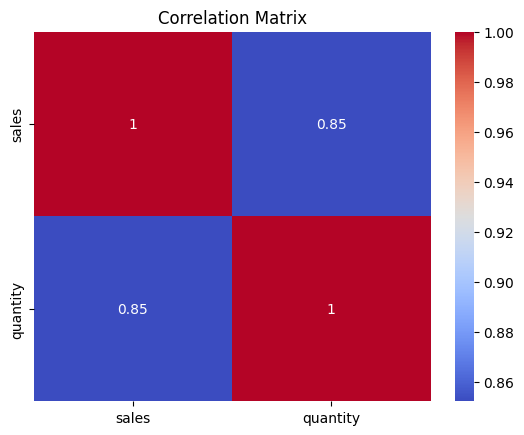

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


uploaded = files.upload()

df = pd.read_csv("sales_data.csv")

print("Original Data:")
print(df)


df['sales'] = df['sales'].fillna(df['sales'].mean())
df['quantity'] = df['quantity'].fillna(df['quantity'].mean())

print("\nAfter Handling Missing Values:")
print(df)


df = df.dropna()

print("\nAfter Removing Remaining Missing Values:")
print(df)


print("\nDescriptive Statistics:")
print(df.describe(include='all'))


result = df.groupby('product')[['sales', 'quantity']].sum()

print("\nSales and Quantity by Product:")
print(result)


total_sales = df.groupby('product')['sales'].sum()

print("\nTotal Sales by Product:")
print(total_sales)


total_sales.plot(kind='bar')

plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')
plt.show()


df.groupby('day')['sales'].sum().plot(
    kind='line',
    marker='o'
)

plt.xlabel('Day')
plt.ylabel('Total Sales')
plt.title('Sales Trend by Day')
plt.show()


pivot = pd.pivot_table(
    df,
    index='day',
    columns='product',
    values='sales',
    aggfunc='sum'
)

print("\nPivot Table:")
print(pivot)


corr = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(corr)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()